# Employee Salary Prediction - Advanced Regression Pipeline

## 1. Business Problem & Project Overview
This project aims to develop a robust, end-to-end Machine Learning pipeline to predict employee salaries based on market data, experience levels, and company characteristics.

**Objective:** Build a scalable, production-ready regression system capable of identifying salary patterns and providing accurate estimations to support HR compensation proposals.

**Key Workflow Steps:**
1. Data Acquisition & Initial Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Engineering (Custom Transformers)
4. Preprocessing Pipelines
5. Model Benchmarking (Dynamic Selection)
6. Automatic Hyperparameter Tuning using Optuna
7. Final Model Evaluation & Diagnostics

## 2. Environment Setup & Imports
Importing all required libraries, setting seeds for reproducibility, and configuring standard plotting styles.

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any

# Preprocessing & Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn import set_config

# Models (Top 5 Regression Algorithms)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb

# Tuning
import optuna

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration
warnings.filterwarnings('ignore')
set_config(transform_output="pandas")
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42

## 3. Data Acquisition & Initial Cleaning
Loading the dataset and applying basic sanity checks.

In [ ]:
# Loads the dataset from the specified path, performs initial cleaning, and removes duplicates.
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    print(f"Loading data from: {filepath}")
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Error: File {filepath} not found. Please ensure the dataset is in the correct directory.")
        raise
        
    initial_shape = df.shape
    df.drop_duplicates(inplace=True)
    final_shape = df.shape
    
    print(f"Initial shape: {initial_shape}")
    print(f"Duplicates dropped: {initial_shape[0] - final_shape[0]}")
    print(f"Final shape: {final_shape}\n")
    
    return df

DATA_PATH = r'C:\Users\arman\OneDrive\Documentos\Proyectos de programacion\Proyectos sin haberse publicado\ML-DL-SQL-MongoDB\601 regresion machine learning\data\job_salary_prediction_dataset.csv'
df = load_and_clean_data(DATA_PATH)

# Target Definition & Leakage Prevention
TARGET_COL = 'salary'
leakage_cols = ['salary']
cols_to_drop = [col for col in leakage_cols if col in df.columns and col != TARGET_COL]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

display(df.head())

Loading data from: C:\Users\arman\OneDrive\Documentos\Proyectos de programacion\Proyectos sin haberse publicado\ML-DL-SQL-MongoDB\601 regresion machine learning\data\job_salary_prediction_dataset.csv
Initial shape: (250000, 10)
Duplicates dropped: 0
Final shape: (250000, 10)



,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 4. Exploratory Data Analysis (EDA)

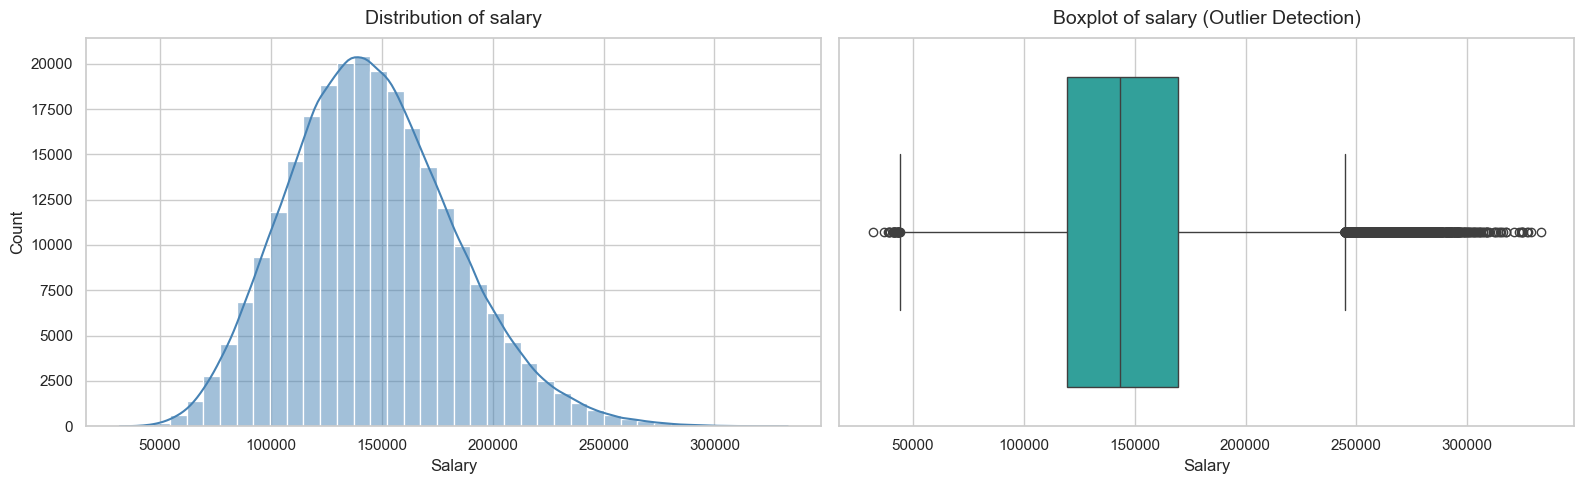

In [5]:
def plot_target_distribution(dataframe: pd.DataFrame, target: str):
    """Plots the distribution and boxplot for the continuous target variable."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    sns.histplot(dataframe[target], kde=True, ax=axes[0], color='steelblue', bins=40)
    axes[0].set_title(f'Distribution of {target}', fontsize=14, pad=10)
    axes[0].set_xlabel('Salary')
    
    sns.boxplot(x=dataframe[target], ax=axes[1], color='lightseagreen')
    axes[1].set_title(f'Boxplot of {target} (Outlier Detection)', fontsize=14, pad=10)
    axes[1].set_xlabel('Salary')
    
    plt.tight_layout()
    plt.show()

plot_target_distribution(df, TARGET_COL)

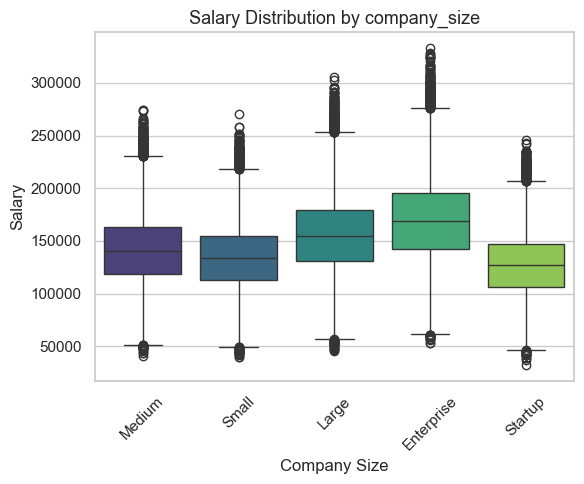

In [ ]:
def plot_categorical_relationships(dataframe: pd.DataFrame, target: str):
    """Analyzes the relationship between key categorical features and the target."""
    potential_cats = ['experience_level', 'company_size', 'employment_type', 'remote_ratio']
    available_cats = [col for col in potential_cats if col in dataframe.columns]
    
    if not available_cats: 
        return

    num_plots = len(available_cats)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 5))
   
    if num_plots == 1: 
        axes = [axes]
        
    for ax, cat_col in zip(axes, available_cats):
        sns.boxplot(data=dataframe, x=cat_col, y=target, ax=ax, palette="viridis")
        ax.set_title(f'Salary Distribution by {cat_col}', fontsize=13)
        ax.set_xlabel(cat_col.replace('_', ' ').title())
        ax.set_ylabel('Salary')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

plot_categorical_relationships(df, TARGET_COL)

## 5. Train-Validation-Test Split

In [ ]:
# Create Train, Validation, and Test Sets
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 1. Split into temporary train and final test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# 2. Split temporary train into actual train and validation (80/20 of the temp)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Testing set shape: {X_test.shape}")

## 6. Custom Feature Engineering Classes
Implementing domain-specific transformations, outlier clipping, and rare category grouping.

In [7]:
# Custom transformer to apply domain-specific feature engineering.
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_out = X.copy()
        # Seasonality (Cyclical encoding for month)
        if 'month' in X_out.columns:
            X_out['month_sin'] = np.sin(2 * np.pi * X_out['month'] / 12)
            X_out['month_cos'] = np.cos(2 * np.pi * X_out['month'] / 12)            
        return X_out

# Clips numerical outliers based on the Interquartile Range (IQR) method.
class IQRTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, iqr_factor=1.5):
        self.iqr_factor = iqr_factor

    def fit(self, X, y=None):
        X_array = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X_array, 25, axis=0)
        self.q3_ = np.nanpercentile(X_array, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.iqr_factor * self.iqr_
        self.upper_ = self.q3_ + self.iqr_factor * self.iqr_
        return self

    def transform(self, X):
        X_array = np.asarray(X, dtype=float)
        clipped_array = np.clip(X_array, self.lower_, self.upper_)
        return pd.DataFrame(clipped_array, columns=X.columns, index=X.index)
        
# Groups infrequent categorical modalities into an 'Other' category.
class RareCategoryEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.columns_ = X_df.columns
        self.freqs_ = {col: X_df[col].value_counts(normalize=True) for col in self.columns_}
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        for col in self.columns_:
            rare = self.freqs_[col][self.freqs_[col] < self.threshold].index
            X_df[col] = X_df[col].replace(rare, "Other")
        return X_df

print("Custom classes defined successfully.")

Custom classes defined successfully.


## 7. Preprocessing Pipelines

In [ ]:
# Dynamically separate feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('iqr_clipper', IQRTransformer(iqr_factor=1.5)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('rare_encoder', RareCategoryEncoder(threshold=0.05)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

data_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("\nPipelines configured successfully.")

Training set shape: (160000, 9)
Validation set shape: (40000, 9)
Testing set shape: (50000, 9)

Pipelines configured successfully.


## 8. Model Benchmarking (Dynamic Evaluation)
Evaluating the top 5 regression models on the validation set to dynamically identify the best baseline algorithm.

Evaluating Ridge Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...


,Model,Validation_R2,Validation_RMSE
3,XGBoost,0.978696,5435.837010
4,LightGBM,0.978007,5523.027003
1,Random Forest,0.970575,6388.492418
0,Ridge Regression,0.963006,7163.121936
2,Gradient Boosting,0.949217,8392.669842


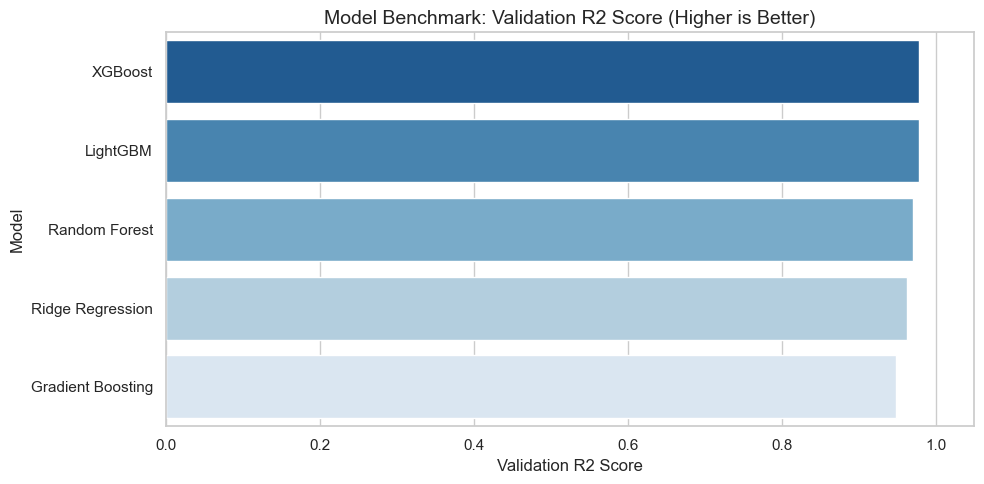

In [ ]:
# Define the benchmark models (Top 5 Regression Models)
benchmark_models = {
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, objective='reg:squarederror'),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
}

# Trains multiple models on the training set and evaluates them on the validation set.
def run_benchmark(models_dict, X_train_split, y_train_split, X_val_split, y_val_split):
    results = []
    
    for name, model in models_dict.items():
        print(f"Evaluating {name}...")
        # Create full pipeline for the current model
        model_pipeline = Pipeline([
            ('feature_engineer', FeatureEngineer()),
            ('data_prep', data_pipeline),
            ('regressor', model)
        ])
        
        # Fit strictly on the training set
        model_pipeline.fit(X_train_split, y_train_split)
        
        # Evaluate on the validation set
        y_val_pred = model_pipeline.predict(X_val_split)
        score_r2 = r2_score(y_val_split, y_val_pred)
        score_rmse = np.sqrt(mean_squared_error(y_val_split, y_val_pred))
        
        results.append({
            'Model': name,
            'Validation_R2': score_r2,
            'Validation_RMSE': score_rmse
        })
        
    results_df = pd.DataFrame(results).sort_values(by='Validation_R2', ascending=False)
    return results_df

# Execute Benchmark
benchmark_results = run_benchmark(benchmark_models, X_train, y_train, X_val, y_val)
display(benchmark_results)

# Plot Benchmark Results
plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_results, x='Validation_R2', y='Model', palette='Blues_r')
plt.title("Model Benchmark: Validation R2 Score (Higher is Better)", fontsize=14)
plt.xlabel("Validation R2 Score")
plt.ylabel("Model")
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

## 9. Automatic Hyperparameter Tuning using Optuna
Dynamically injecting the best baseline model into an Optuna study to find the most optimal hyperparameters for production.

In [ ]:
# Dynamically identify the best model from the benchmarking step
best_model_name = benchmark_results.iloc[0]['Model']
print(f"Best model automatically selected for tuning: {best_model_name}")

# Returns the hyperparameter search space specific to the selected model.
def get_optuna_params(trial, model_name):
    if model_name == 'Ridge Regression':
        return {
            'alpha': trial.suggest_float('alpha', 0.01, 10.0, log=True)
        }
    elif model_name == 'Random Forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
        }

    elif model_name == 'Gradient Boosting':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }

    elif model_name == 'XGBoost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0)
        }

    elif model_name == 'LightGBM':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }
    
    return {}

# Merges fixed base parameters with dynamic Optuna parameters and instantiates the selected model.
def get_model_instance(model_name, dynamic_params):
    base_params = {}

    if model_name == 'Ridge Regression':
        base_params = {'random_state': RANDOM_STATE}
        base_params.update(dynamic_params)
        return Ridge(**base_params)
    elif model_name == 'Random Forest':
        base_params = {'random_state': RANDOM_STATE}
        base_params.update(dynamic_params)
        return RandomForestRegressor(**base_params)
    elif model_name == 'Gradient Boosting':
        base_params = {'random_state': RANDOM_STATE}
        base_params.update(dynamic_params)
        return GradientBoostingRegressor(**base_params)
    elif model_name == 'XGBoost':
        base_params = {'random_state': RANDOM_STATE, 'objective': 'reg:squarederror'}
        base_params.update(dynamic_params)
        return xgb.XGBRegressor(**base_params)
    elif model_name == 'LightGBM':
        base_params = {'random_state': RANDOM_STATE, 'verbose': -1}
        base_params.update(dynamic_params)
        return lgb.LGBMRegressor(**base_params)
    raise ValueError(f"Model {model_name} is not supported.")

def objective(trial, model_name, X_train_split, y_train_split, X_val_split, y_val_split):
    # 1. Fetch parameters dynamically
    params = get_optuna_params(trial, model_name)
    model_instance = get_model_instance(model_name, params)
    
    # 2. Build Pipeline
    full_pipeline = Pipeline([
        ('feature_engineer', FeatureEngineer()),
        ('data_prep', data_pipeline),
        ('regressor', model_instance)
    ])
    
    # 3. Fit strictly on the training set
    full_pipeline.fit(X_train_split, y_train_split)
    
    # 4. Evaluate explicitly on the validation set
    y_val_pred = full_pipeline.predict(X_val_split)
    
    # We maximize R2 Score
    score = r2_score(y_val_split, y_val_pred)
    return score

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')

print(f"Starting Optuna Tuning for {best_model_name}...")
study.optimize(lambda trial: objective(trial, best_model_name, X_train, y_train, X_val, y_val), n_trials=10, show_progress_bar=True)

print("Optimization Completed.")
print(f"Best Validation R2-Score: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

Best model automatically selected for tuning: XGBoost
Starting Optuna Tuning for XGBoost...


  0%|          | 0/10 [00:00<?, ?it/s]

Optimization Completed.
Best Validation R2-Score: 0.9810
Best Parameters: {'n_estimators': 741, 'learning_rate': 0.053075746489078424, 'max_depth': 5, 'subsample': 0.7688825118875618}


## 10. Final Model Evaluation & Diagnostics
Training the model with the best parameters combining train and validation sets, and evaluating it securely on the unseen test set.

In [11]:
# Combine Train and Validation sets for final training
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

# Build final model instance with the discovered best parameters
final_model_instance = get_model_instance(best_model_name, study.best_params)

final_pipeline = Pipeline([
    ('feature_engineer', FeatureEngineer()),
    ('data_prep', data_pipeline),
    ('regressor', final_model_instance)
])

final_pipeline.fit(X_full_train, y_full_train)

# Predictions strictly on the Test Set
y_pred = final_pipeline.predict(X_test)

# Calculate Final Metrics
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Final Test Set Metrics:")
print("-" * 25)
print(f"MAE:  {test_mae:,.2f}")
print(f"RMSE: {test_rmse:,.2f}")
print(f"R2:   {test_r2:.4f}")

Final Test Set Metrics:
-------------------------
MAE:  4,065.20
RMSE: 5,094.07
R2:   0.9813


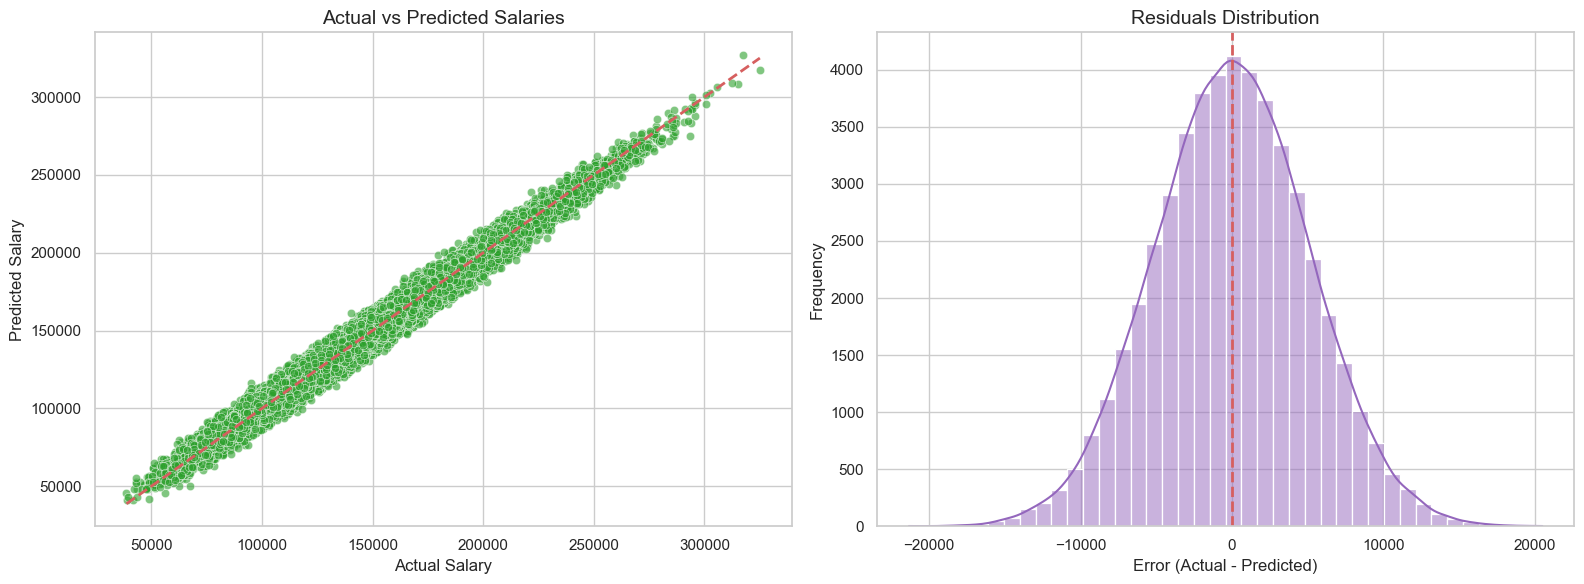

In [12]:
def plot_regression_diagnostics(y_true: pd.Series, y_pred: np.ndarray):
    """Plots Actual vs Predicted and Residuals Distribution."""
    residuals = y_true - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Actual vs Predicted
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, color='#2ca02c', ax=axes[0])
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    axes[0].set_title('Actual vs Predicted Salaries', fontsize=14)
    axes[0].set_xlabel('Actual Salary')
    axes[0].set_ylabel('Predicted Salary')
    
    # Residuals Distribution
    sns.histplot(residuals, kde=True, ax=axes[1], color='#9467bd', bins=40)
    axes[1].axvline(0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Residuals Distribution', fontsize=14)
    axes[1].set_xlabel('Error (Actual - Predicted)')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

plot_regression_diagnostics(y_test, y_pred)